In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import seaborn as sns

In [3]:
df = pd.read_csv('Advertising.csv')

In [4]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


Text(0.5, 1.0, 'Newspaper Spend')

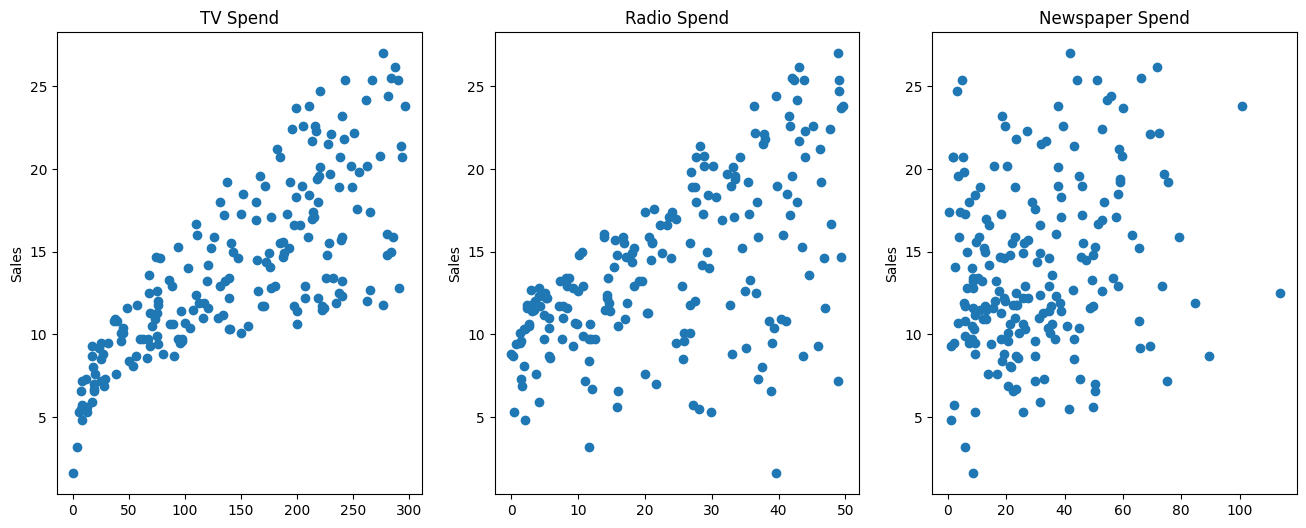

In [5]:
fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize= (16,6))

axes[0].plot(df['TV'], df['sales'], 'o')
axes[0].set_ylabel('Sales')
axes[0].set_title('TV Spend')

axes[1].plot(df['radio'], df['sales'], 'o')
axes[1].set_ylabel('Sales')
axes[1].set_title('Radio Spend')

axes[2].plot(df['newspaper'], df['sales'], 'o')
axes[2].set_ylabel('Sales')
axes[2].set_title('Newspaper Spend')

In [6]:
#sns.pairplot(df)

In [7]:
X = df.drop( 'sales', axis = 1)

In [8]:
y = df['sales']

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [11]:
len(df)

200

In [12]:
len(X_train)

160

In [13]:
len(X_test)

40

In [14]:
from sklearn.linear_model import LinearRegression

In [15]:
#help(LinearRegression)

In [16]:
model = LinearRegression()

In [17]:
model.fit(X_train, y_train)

LinearRegression()

In [18]:
test_predictions = model.predict(X_test)

In [19]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [20]:
df['sales'].mean()

np.float64(14.0225)

<Axes: xlabel='sales', ylabel='Count'>

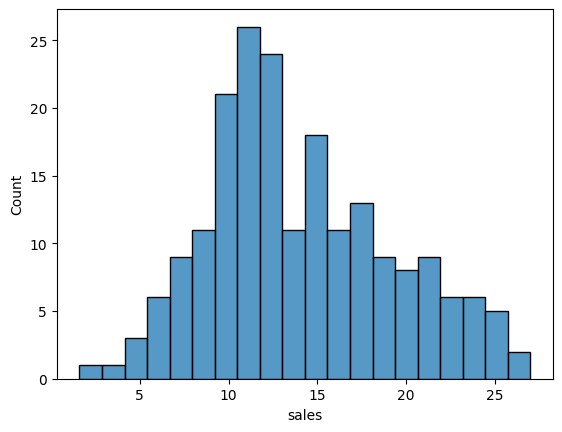

In [21]:
sns.histplot(data = df, x = 'sales', bins = 20)

In [22]:
mean_absolute_error(y_test, test_predictions)

1.4607567168117603

In [23]:
# RMSE
np.sqrt(mean_squared_error(y_test, test_predictions))

np.float64(1.78159966153345)

In [24]:
test_residuals = y_test - test_predictions

In [25]:
#test_residuals

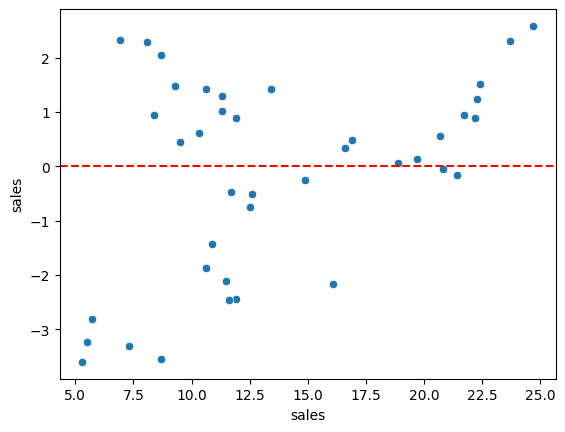

In [26]:
sns.scatterplot(x = y_test, y = test_residuals )
plt.axhline(y=0, color = 'red',ls ='--' )

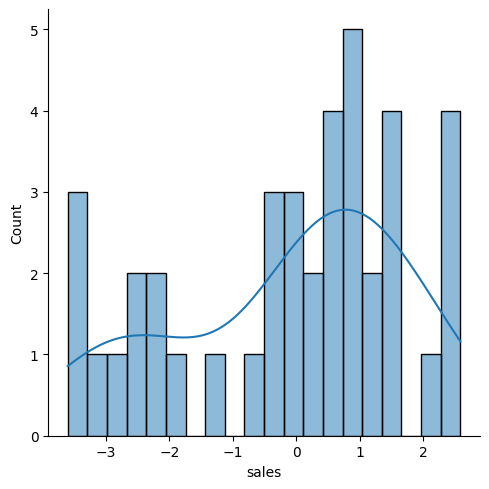

In [27]:
sns.displot(test_residuals, bins = 20, kde = True)

In [28]:
import scipy as sp

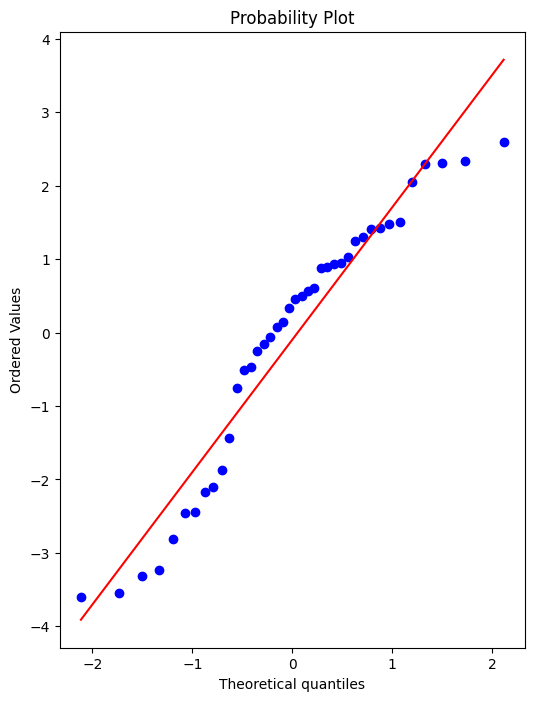

In [29]:
fig, ax = plt.subplots(figsize= (6,8), dpi = 100)

# probplot return the raw values if needed

_ = sp.stats.probplot(test_residuals, plot = ax)

In [30]:
final_model = LinearRegression()

In [31]:
final_model.fit(X,y)

LinearRegression()

In [32]:
final_model.coef_

array([ 0.04576465,  0.18853002, -0.00103749])

In [33]:
X.head()

,TV,radio,newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


In [34]:
y_hat = final_model.predict(X)

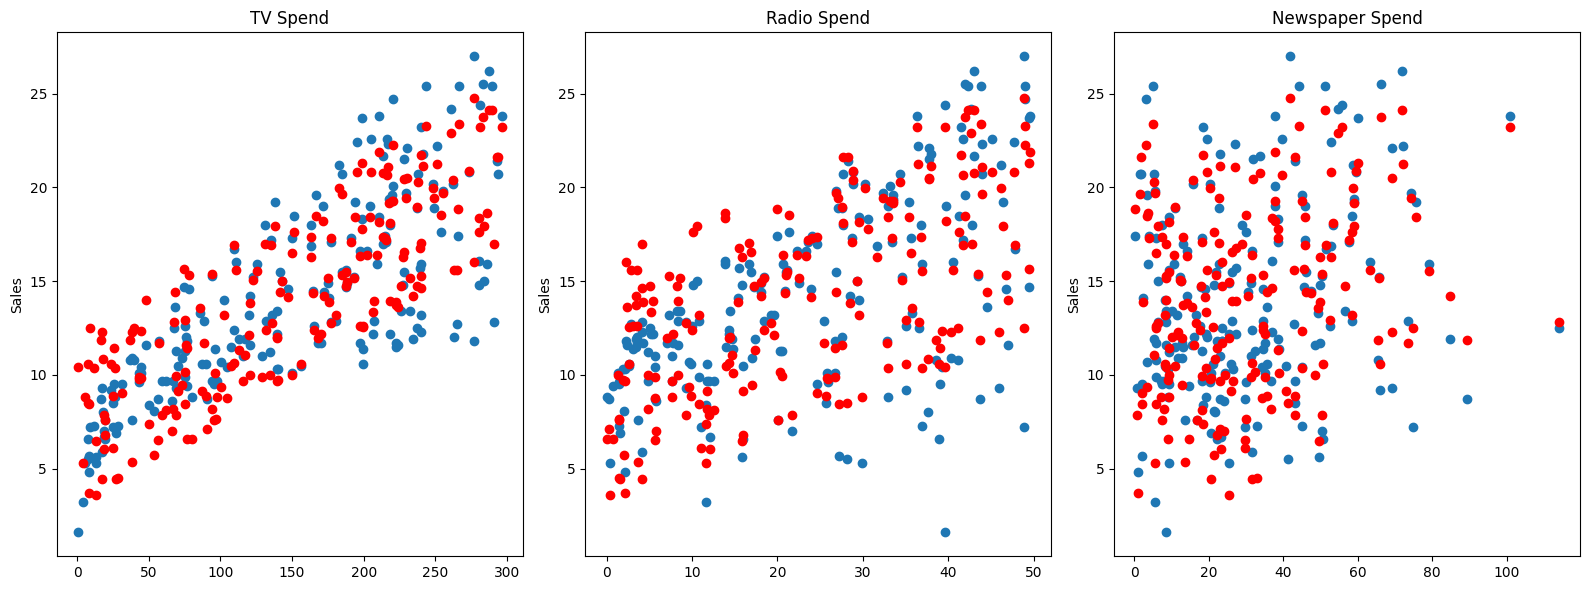

In [38]:
fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize= (16,6))

axes[0].plot(df['TV'], df['sales'], 'o')
axes[0].plot(df['TV'], y_hat, 'o', color = 'red')
axes[0].set_ylabel('Sales')
axes[0].set_title('TV Spend')

axes[1].plot(df['radio'], df['sales'], 'o')
axes[1].plot(df['radio'], y_hat, 'o', color = 'red')
axes[1].set_ylabel('Sales')
axes[1].set_title('Radio Spend')

axes[2].plot(df['newspaper'], df['sales'], 'o')
axes[2].plot(df['newspaper'], y_hat, 'o', color = 'red')
axes[2].set_ylabel('Sales')
axes[2].set_title('Newspaper Spend')
plt.tight_layout()

In [40]:
from joblib import dump, load

In [41]:
dump(final_model, 'final_sales_model.joblib' )

['final_sales_model.joblib']

In [42]:
loaded_model = load('final_sales_model.joblib')

In [43]:
loaded_model.coef_

array([ 0.04576465,  0.18853002, -0.00103749])

In [44]:
X.shape

(200, 3)

In [45]:
# 149 TV, 22 radio, 12 newspaper
# sales = ??
campaign = [[149,22,12]]

In [46]:
loaded_model.predict(campaign)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([13.893032])